# Set D

In [565]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings('ignore')

In [566]:
#URL
url = 'https://renatomaaliw3.github.io/prelims.html'

#Send Request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36'}


# Response

response = requests.get(url = url, headers = headers)

#Create a bs4 object to parse the html content
prelimTable = BeautifulSoup(response.content, 'html.parser')

In [567]:
setD = prelimTable.select('table#set_d')

In [568]:
#setD = prelimTable.select('tbody', class_ = 'tbody-04')

In [569]:
table_1 = prelimTable.select_one('table#set_d')

if table_1:

  th_elements = table_1.select('thead th')
  if th_elements:
    header_names = [th.get_text().strip() for th in th_elements]

header_names

['Date', 'Value']

In [570]:
data = []
table_rows = prelimTable.select('table#set_d > tbody > tr')
for row in table_rows:
  cols = [col.get_text(strip = True) for col in row.find_all('td')]
  data.append(cols)

data

[['1979-01-01', '10.99342831'],
 ['1979-01-02', '10.80723229'],
 ['1979-01-03', '13.42542612'],
 ['1979-01-04', '16.14040851'],
 ['1979-01-05', '13.46708864'],
 ['1979-01-06', '14.14874253'],
 ['1979-01-07', '18.26818948'],
 ['1979-01-08', '16.92713165'],
 ['1979-01-09', '14.51326381'],
 ['1979-01-10', '16.37212456'],
 ['1979-01-11', '13.97707049'],
 ['1979-01-12', '13.38836058'],
 ['1979-01-13', '14.04454096'],
 ['1979-01-14', '8.833500631'],
 ['1979-01-15', '8.208556897'],
 ['1979-01-16', '9.476025542'],
 ['1979-01-17', '7.508821607'],
 ['1979-01-18', '9.137063243'],
 ['1979-01-19', '5.753931803'],
 ['1979-01-20', '3.937751519'],
 ['1979-01-21', '9.055214401'],
 ['1979-01-22', '5.234162078'],
 ['1979-01-23', '5.605300152'],
 ['1979-01-24', '2.640877062'],
 ['1979-01-25', '4.659948839'],
 ['1979-01-26', '6.459273014'],
 ['1979-01-27', '4.636507627'],
 ['1979-01-28', '8.575829098'],
 ['1979-01-29', '7.658160005'],
 ['1979-01-30', '9.417505717'],
 ['1979-01-31', '9.997787977'],
 ['1979-

In [571]:
data_df = pd.DataFrame(data, columns = header_names)
data_df

,Date,Value
0,1979-01-01,10.99342831
1,1979-01-02,10.80723229
2,1979-01-03,13.42542612
3,1979-01-04,16.14040851
4,1979-01-05,13.46708864
...,...,...
995,1981-09-22,70.85892297
996,1981-09-23,77.19454533
997,1981-09-24,76.02483233
998,1981-09-25,73.66073902


In [572]:
# Convert 'Date' column to datetime objects
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert 'Value' column to float
data_df['Value'] = data_df['Value'].astype(float)

data_df.dtypes


,0
Date,datetime64[ns]
Value,float64


In [573]:
data_df.reset_index(drop = True, inplace = True)
data_df

,Date,Value
0,1979-01-01,10.993428
1,1979-01-02,10.807232
2,1979-01-03,13.425426
3,1979-01-04,16.140409
4,1979-01-05,13.467089
...,...,...
995,1981-09-22,70.858923
996,1981-09-23,77.194545
997,1981-09-24,76.024832
998,1981-09-25,73.660739


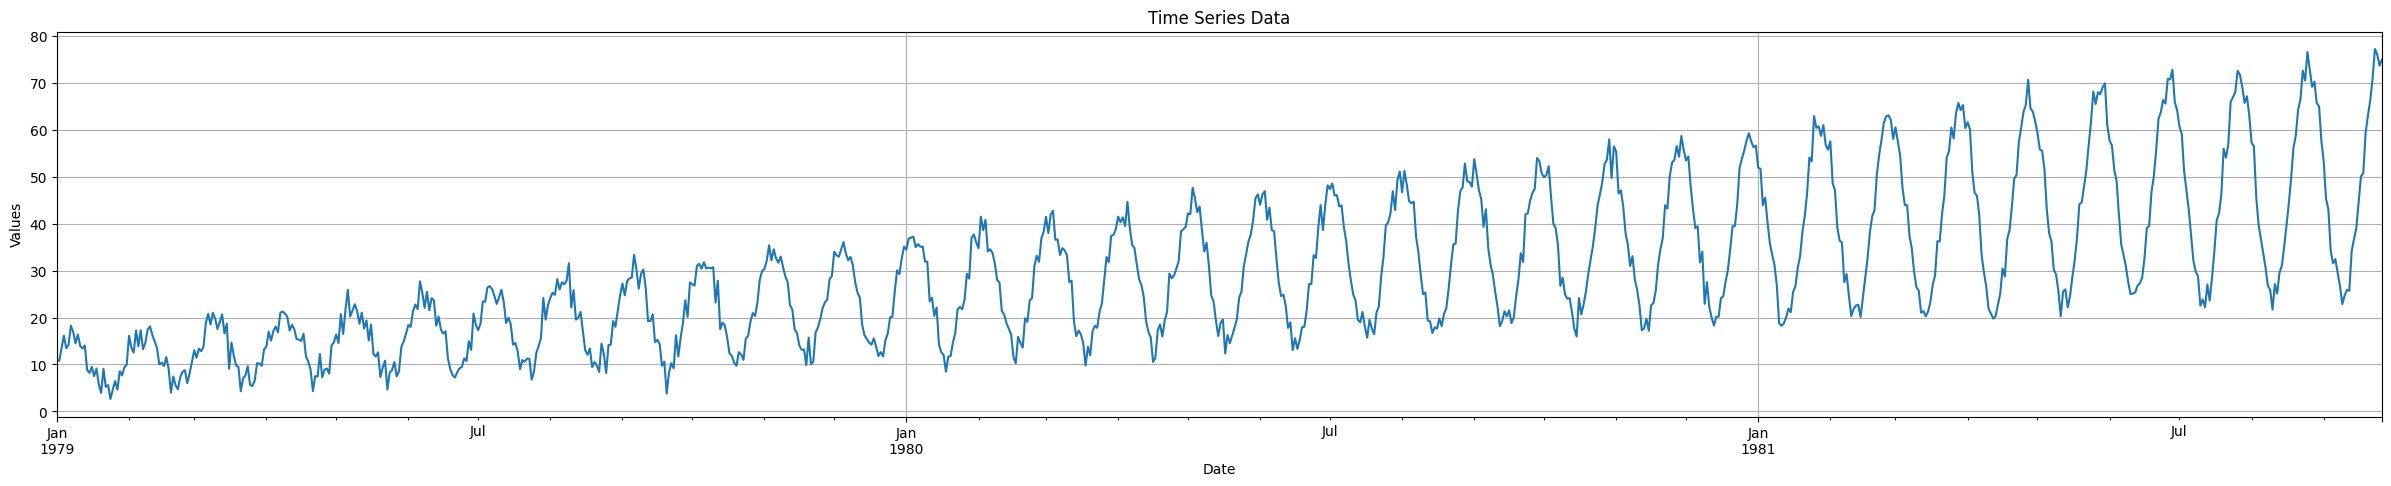

In [574]:
ts = data_df.set_index('Date')['Value']
ts.plot(figsize=(30, 5), grid=True, ylabel='Values', title='Time Series Data')
plt.show()


# 1.What is the appropriate model for your dataset (SES, DES, TES)?
# Answer: (TES) Triple Exponential Smoothing

Check for trend and seasonability

In [575]:
# STL Decomposition

from statsmodels.tsa.seasonal import STL

ts_stl = STL(ts, robust=True)
decomp_stl = ts_stl.fit()

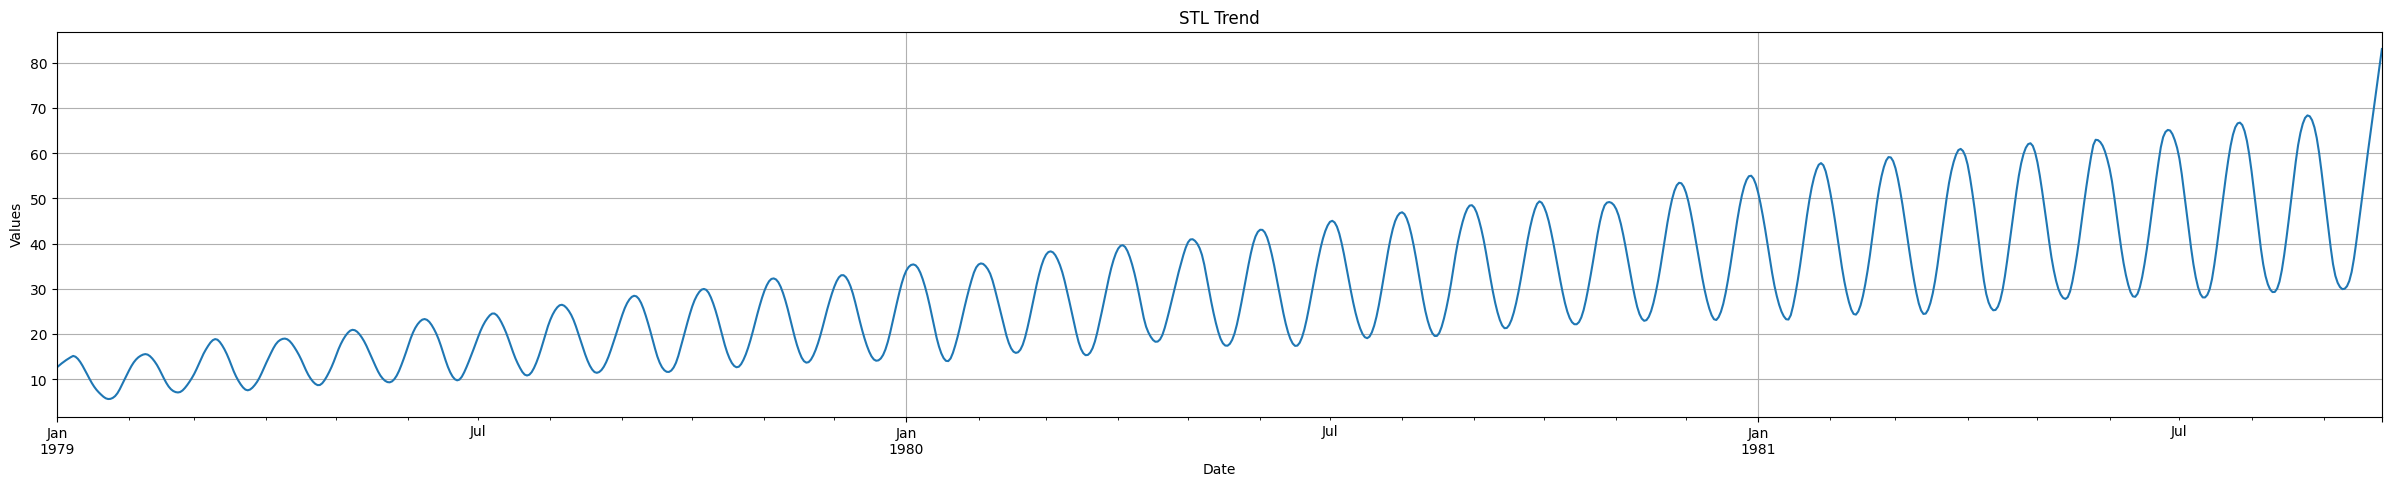

In [576]:
# STL Trend

decomp_stl.trend.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Trend')
plt.show()

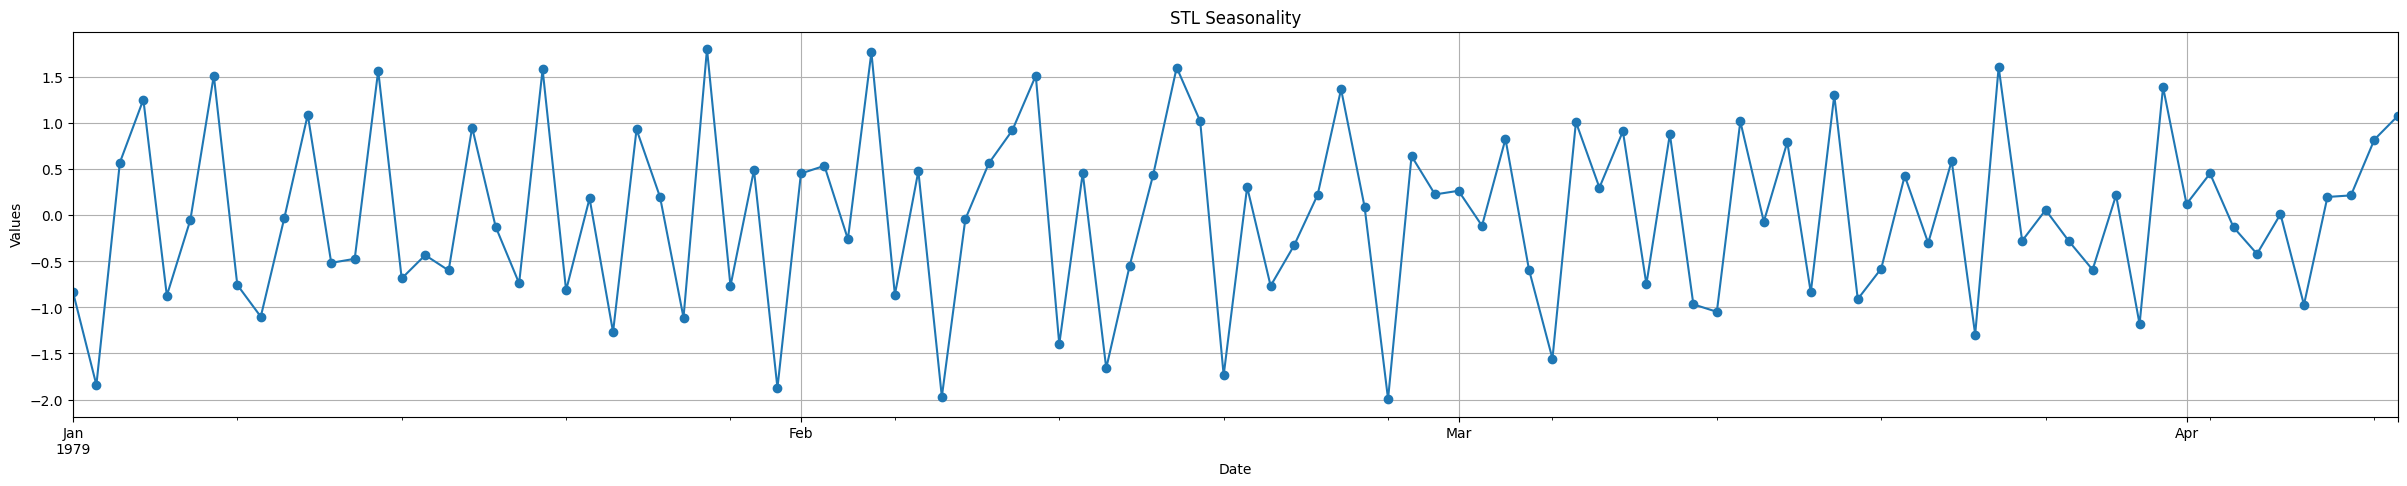

In [577]:
# STL Seasonality

decomp_stl.seasonal[:100].plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Seasonality', marker = 'o')
plt.show()

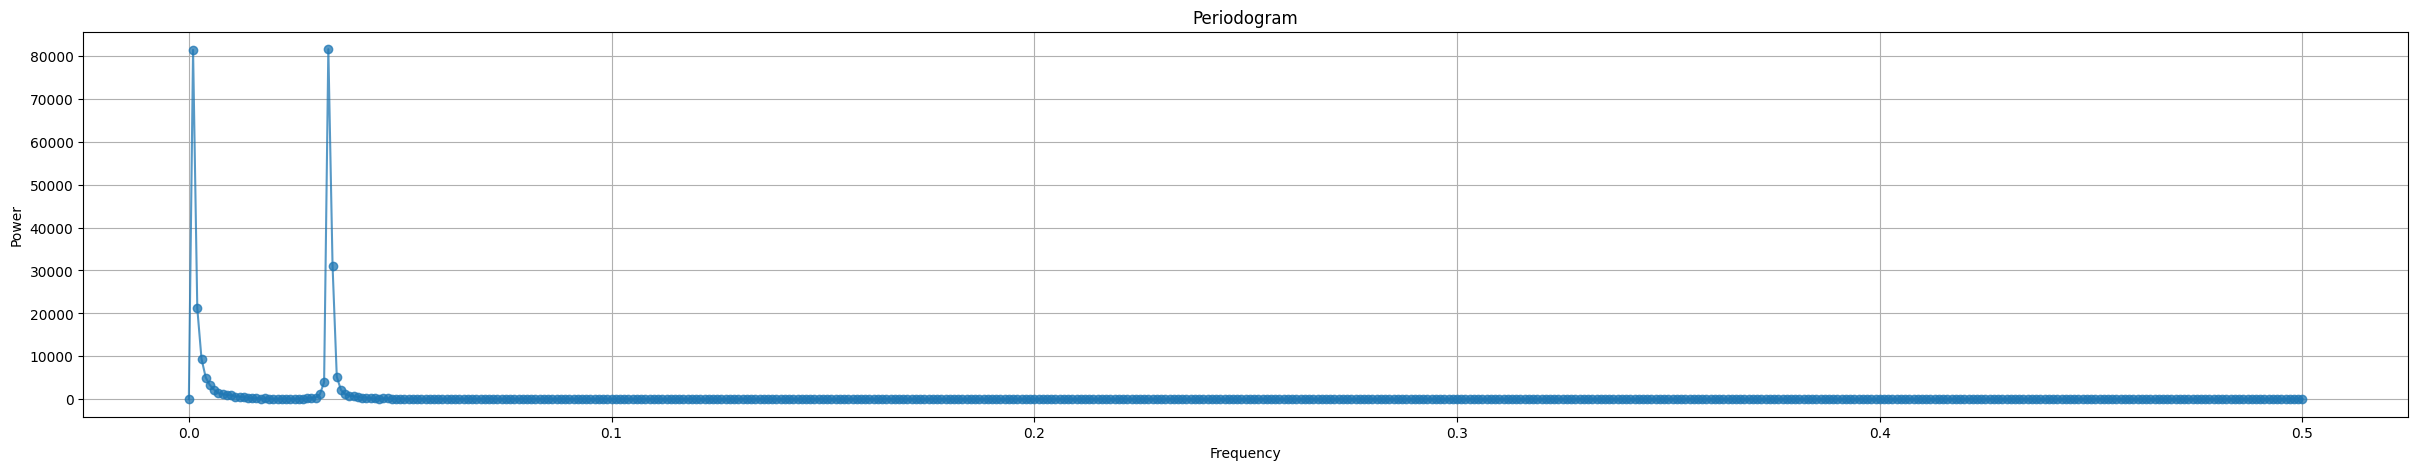

In [578]:
# Periodogram (for Seasonality)

from scipy.signal import periodogram

# Compute the periodogram
frequencies, power = periodogram(ts.values)

# Plot the periodogram
plt.figure(figsize=(30, 5))
plt.plot(frequencies, power, marker='o', linestyle='-', alpha=0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

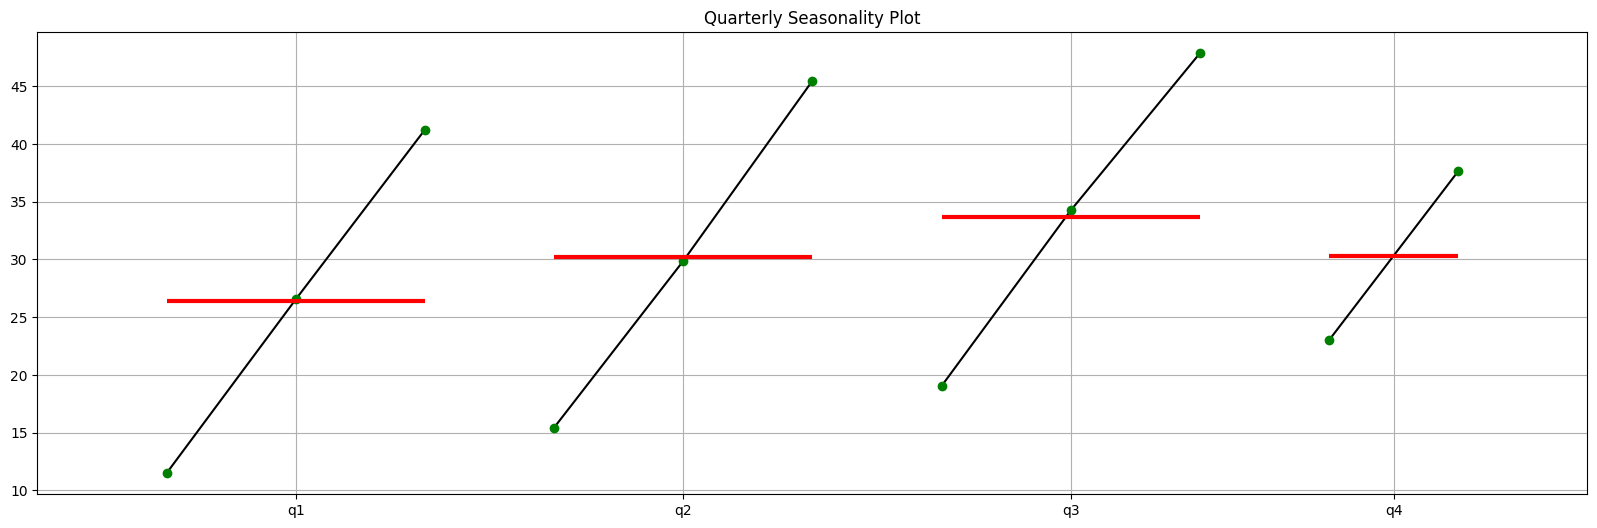

In [579]:
from statsmodels.graphics.tsaplots import quarter_plot

ts_quarter = ts.resample('QE').mean()

fig, ax = plt.subplots(figsize=(20, 6))
quarter_plot(ts_quarter, ax=ax)
plt.title("Quarterly Seasonality Plot")
plt.grid()

for line in ax.get_lines():
    line.set_marker('o')
    line.set_markerfacecolor('green')
    line.set_markeredgecolor('green')

plt.show()


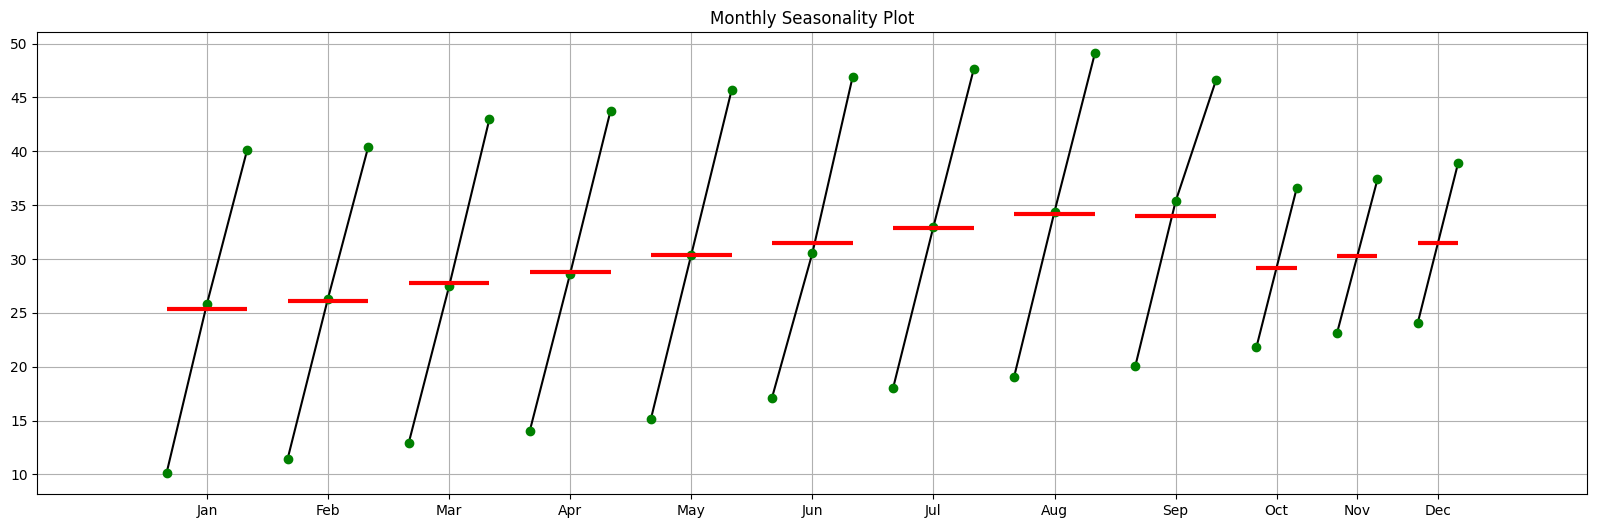

In [580]:
from statsmodels.graphics.tsaplots import month_plot

ts_monthly = ts.resample('MS').mean()

fig, ax = plt.subplots(figsize=(20, 6))
month_plot(ts_monthly, ax = ax)
plt.title("Monthly Seasonality Plot")
plt.grid()

for line in ax.get_lines():

  line.set_marker('o')
  line.set_markerfacecolor('green')
  line.set_markeredgecolor('green')

plt.show()

In [581]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [582]:
# Splitting

forecast_horizon = 21

train_data = ts.iloc[:-forecast_horizon]
test_data = ts.iloc[-forecast_horizon:]

train_data = train_data.asfreq('ME')
test_data = test_data.asfreq('ME')


In [583]:
tes_model = ExponentialSmoothing(train_data, trend = 'add', seasonal = 'multiplicative', seasonal_periods = 12)
tes_model_fit = tes_model.fit()

tes_model_fit.summary()

Dep. Variable:,Value,No. Observations:,32
Model:,ExponentialSmoothing,SSE,84.679
Optimized:,True,AIC,63.140
Trend:,Additive,BIC,86.592
Seasonal:,Multiplicative,AICC,115.755
Seasonal Periods:,12,Date:,"Thu, 27 Mar 2025"
Box-Cox:,False,Time:,06:02:34
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4071038,alpha,True
smoothing_trend,0.4071038,beta,True


In [584]:
tes_pred = tes_model_fit.forecast(forecast_horizon)
tes_pred

,0
1981-09-30,61.034131
1981-10-31,64.736598
1981-11-30,61.194264
1981-12-31,62.681598
1982-01-31,60.763278
1982-02-28,61.627208
1982-03-31,62.035124
1982-04-30,61.834996
1982-05-31,62.988052
1982-06-30,64.632323


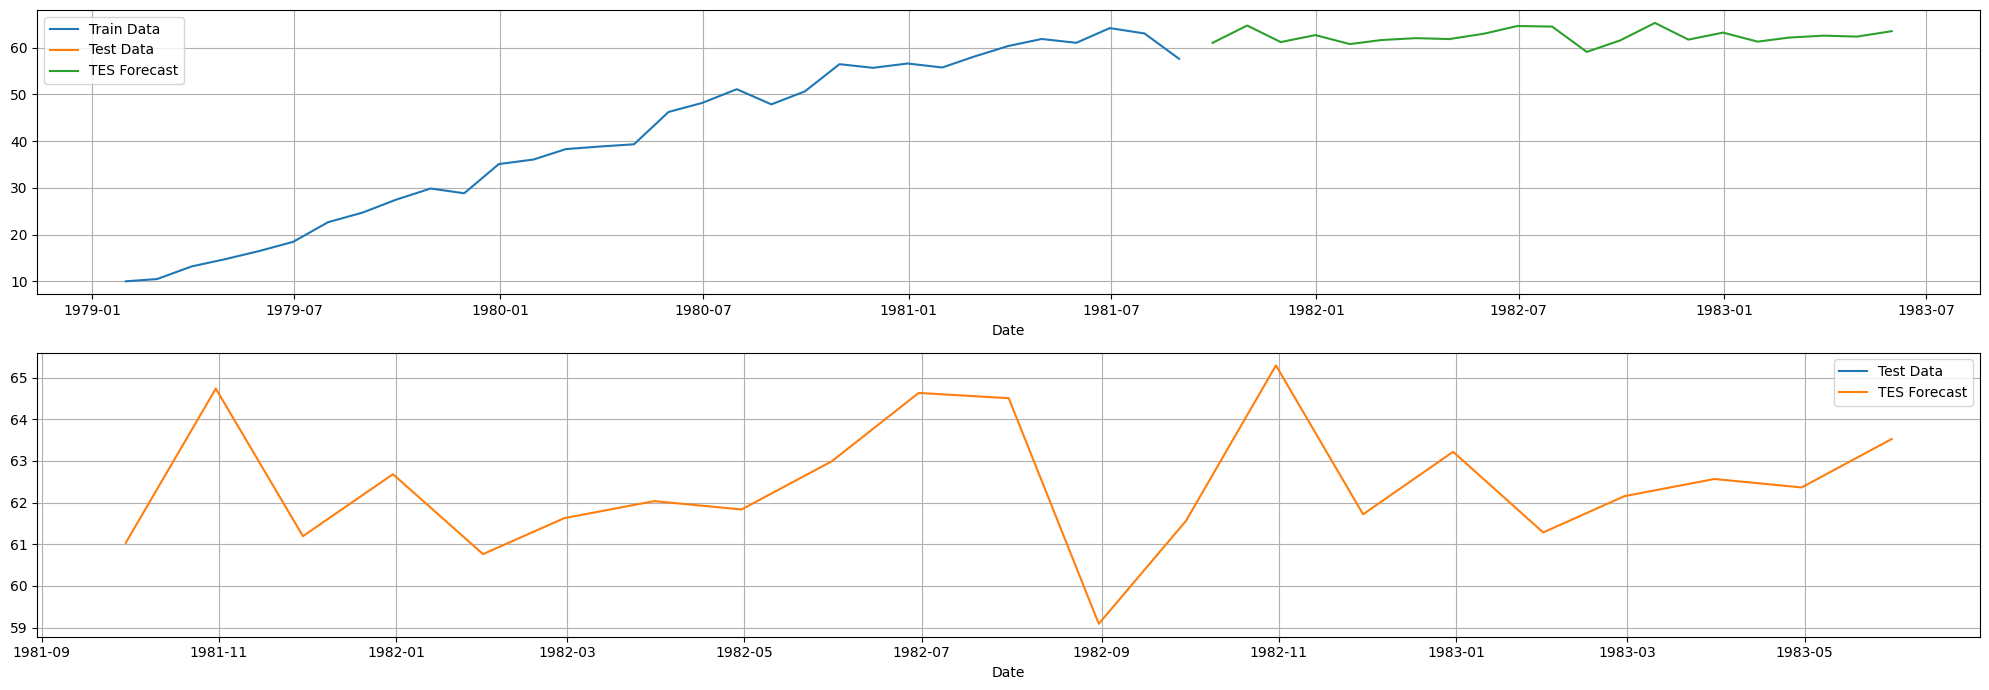

In [585]:
# Visualization

plt.figure(figsize=(20, 7))
plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(tes_pred.index, tes_pred, label='TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.tight_layout()
plt.show()


In [586]:
ts = ts.asfreq('ME')

tes_model_fit = ExponentialSmoothing(ts, trend = 'additive', seasonal = 'multiplicative', seasonal_periods = 12).fit()

In [587]:
tes_pred = tes_model_fit.forecast(forecast_horizon)
tes_pred

,0
1981-09-30,61.034131
1981-10-31,64.736598
1981-11-30,61.194264
1981-12-31,62.681598
1982-01-31,60.763278
1982-02-28,61.627208
1982-03-31,62.035124
1982-04-30,61.834996
1982-05-31,62.988052
1982-06-30,64.632323


# 2. If you have a 21 day forecasting horizon, what is the forecast value on the 14th day against the test data of your chosen model (trained on the training data only)?

In [588]:
tes_pred[13]

np.float64(65.292677245555)

# 3.If you have a 21 day forecasting horizon, what is the forecast value on the 21st day beyond the given data of your chosen model (trained on the whole dataset)?

In [589]:
tes_model_fit = ExponentialSmoothing(ts, trend='additive', seasonal='multiplicative', seasonal_periods=12).fit()
tes_pred = tes_model_fit.forecast(forecast_horizon)
tes_pred[20]


np.float64(63.52641445199223)

Text(0.5, 0, 'Date')

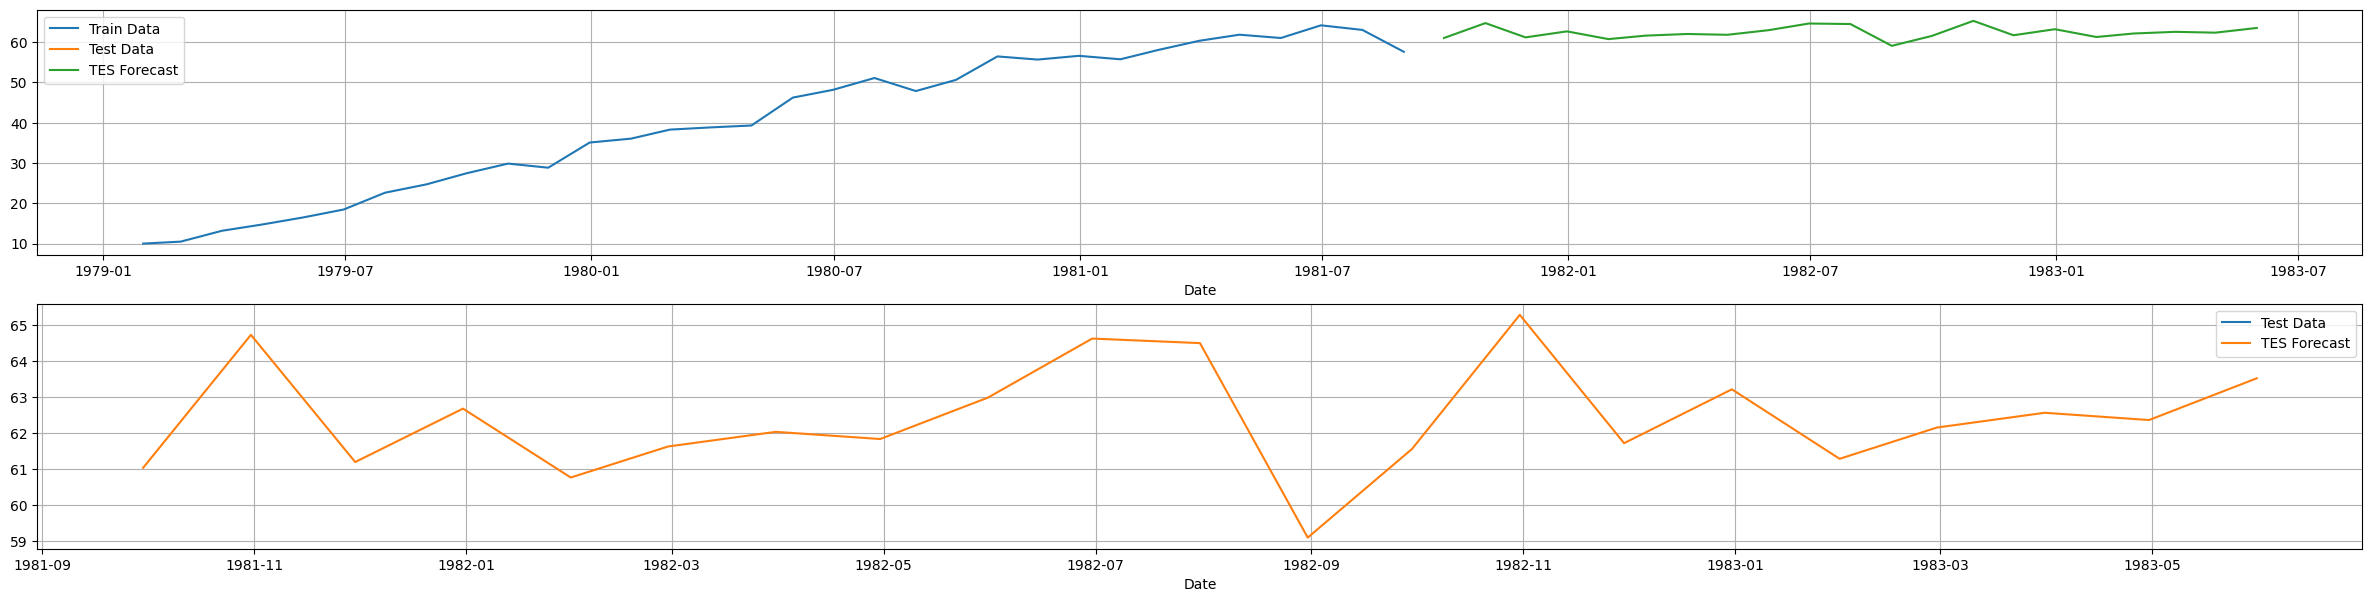

In [590]:
# Visualization

plt.figure(figsize = (30, 7))

plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data, label = 'Train Data')
plt.plot(test_data.index, test_data, label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data, label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')